# Phase 9 — Shadow Model Membership Inference Attack

**Thesis:** Code Division Modulation Layers Against Forgetting and Inference in Continual Gait Identification

---

## Why shadow models?

All previous attacks (CE loss threshold, logit threshold) are **score-based**: they pick one fixed
threshold and classify. Shadow model attacks are **learned**: an attack classifier is trained that
recognises the statistical fingerprint of membership from the model's output distribution.
They are the gold standard in MIA research (Shokri et al. 2017).

## Protocol

1. **Train shadow models** that mimic the target's training process.
   For each shadow model we know exactly which samples are members/non-members.
2. **Extract attack features** from shadow model outputs (CE loss, confidence, entropy, margin).
3. **Train an attack classifier** (logistic regression) on those features.
4. **Apply** the attack classifier to the real target model → AUC / EER.

## The three target models

| Model | Description |
|---|---|
| **Std** | Standard fine-tuning — baseline |
| **CDML** | Sequence-scrambled feature space (paper's method) |
| **CDML+KD** | CDML + focal distillation regularisation (Phase 5) |

## Three attacker levels for CDML

| Attacker | Shadow models | Meaning |
|---|---|---|
| **Naive** | Plain GaitCNN, no CDML | Doesn't know CDML exists |
| **Informed** | CDML with random wrong seeds | Knows CDML structure, not the seed |
| **Oracle** | CDML with correct seeds | Upper bound — seed is known |

The naive and informed attackers represent realistic threat scenarios.
The oracle is a theoretical upper bound to understand how much the seed actually protects.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import (
    DataLoader, TensorDataset, random_split, ConcatDataset, Subset
)
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_curve, auc as sk_auc
from sklearn.preprocessing import StandardScaler
from copy import deepcopy
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 11,
})

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')
print(f'Device: {DEVICE}  |  PyTorch: {torch.__version__}')

Device: mps  |  PyTorch: 2.8.0


## 1. Configuration

In [2]:
TRAIN_DATA_DIR = '../Data/Dataset_1/train'
TEST_DATA_DIR  = '../Data/Dataset_1/test'

N_CHANNELS      = 6
WINDOW_SIZE     = 128
VAL_SPLIT       = 0.15
RANDOM_SEED     = 27
BATCH_SIZE      = 64
EMBED_DIM       = 128
N_CLASSES_TOTAL = 118
CDML_SEED_BASE  = 1000

EPOCHS   = 50   # 100 fast | 400 paper-accurate
LR_INIT  = 1e-3
LR_DECAY = 0.98

TASK_SPLITS = {
    'Task 1': (1,   30),
    'Task 2': (31,  60),
    'Task 3': (61,  90),
    'Task 4': (91, 118),
}

# ── KD-CL hyperparameters (from Phase 5) ─────────────────────────────────────
KD_LAMBDA        = 0.001   # distillation weight
KD_ALPHA         = 0.0    # base weight (focal: 0)
KD_BETA          = 1.0    # correct-sample weight (focal: 1)
MEMORY_FRACTION  = 0.20   # fraction of past task data kept in buffer

# ── Shadow model attack ───────────────────────────────────────────────────────
N_SHADOW         = 4      # number of shadow models per target method
                          # Each shadow model uses a random 50% split of training data
                          # More shadow models = better attack classifier, but more compute
SHADOW_EPOCHS    = 30     # shadow models need fewer epochs (we care about output distribution)
MEMBER_FRAC      = 0.50   # fraction of training data used as members per shadow model

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print('Configuration set.')
print(f'Shadow models: {N_SHADOW} per target  |  Member fraction: {MEMBER_FRAC:.0%}')

Configuration set.
Shadow models: 4 per target  |  Member fraction: 50%


## 2. Data loading

In [3]:
def load_split(data_dir, prefix):
    axes = ['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z']
    signals = [np.loadtxt(f'{data_dir}/Inertial_Signals/{prefix}_{a}.txt') for a in axes]
    X = np.stack(signals, axis=1).astype(np.float32)
    y = np.loadtxt(f'{data_dir}/y_{prefix}.txt', dtype=int)
    return X, y

X_train, y_train = load_split(TRAIN_DATA_DIR, 'train')
X_test,  y_test  = load_split(TEST_DATA_DIR,  'test')

ch_mean = X_train.mean(axis=(0, 2), keepdims=True)
ch_std  = X_train.std(axis=(0, 2),  keepdims=True) + 1e-8
X_train_norm = (X_train - ch_mean) / ch_std
X_test_norm  = (X_test  - ch_mean) / ch_std

unique_labels = np.sort(np.unique(np.concatenate([y_train, y_test])))
label_to_idx  = {lbl: idx for idx, lbl in enumerate(unique_labels)}
y_train_idx   = np.array([label_to_idx[l] for l in y_train])
y_test_idx    = np.array([label_to_idx[l] for l in y_test])

def make_task_datasets(X_tr, y_tr_orig, y_tr_idx, X_te, y_te_orig, y_te_idx,
                       task_splits, val_split, seed):
    rng = torch.Generator().manual_seed(seed)
    task_data = {}
    for task_name, (lo, hi) in task_splits.items():
        mask_tr = (y_tr_orig >= lo) & (y_tr_orig <= hi)
        X_t = torch.tensor(X_tr[mask_tr])
        y_t = torch.tensor(y_tr_idx[mask_tr], dtype=torch.long)
        full = TensorDataset(X_t, y_t)
        n_val = max(1, int(len(full) * val_split))
        train_ds, val_ds = random_split(full, [len(full) - n_val, n_val], generator=rng)
        mask_te = (y_te_orig >= lo) & (y_te_orig <= hi)
        test_ds = TensorDataset(torch.tensor(X_te[mask_te]),
                                torch.tensor(y_te_idx[mask_te], dtype=torch.long))
        task_data[task_name] = {'train': train_ds, 'val': val_ds, 'test': test_ds}
        print(f'{task_name}: {len(train_ds)} train | {n_val} val | {len(test_ds)} test')
    return task_data

task_data  = make_task_datasets(
    X_train_norm, y_train, y_train_idx,
    X_test_norm,  y_test,  y_test_idx,
    TASK_SPLITS, VAL_SPLIT, RANDOM_SEED
)
task_names = list(TASK_SPLITS.keys())
n_tasks    = len(task_names)
print(f'\nTrain: {X_train.shape}  Test: {X_test.shape}')

Task 1: 7347 train | 1296 val | 975 test
Task 2: 7241 train | 1277 val | 962 test
Task 3: 6540 train | 1153 val | 871 test
Task 4: 7013 train | 1237 val | 932 test

Train: (33104, 6, 128)  Test: (3740, 6, 128)


## 3. Model definitions — Std, CDML, CDML+KD

In [4]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, pool=2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=kernel_size, padding=kernel_size//2),
            nn.ReLU(), nn.MaxPool1d(pool),
        )
    def forward(self, x): return self.block(x)


class GaitCNN(nn.Module):
    """Baseline CNN — identical to all previous phases."""
    def __init__(self, n_channels=6, n_classes=118, embed_dim=128):
        super().__init__()
        self.embed_dim = embed_dim
        self.feature_extractor = nn.Sequential(
            ConvBlock(n_channels, 32), ConvBlock(32, 64),
            ConvBlock(64, 128),        ConvBlock(128, 128), nn.Flatten(),
        )
        flat = self.feature_extractor(torch.zeros(1, n_channels, WINDOW_SIZE)).shape[1]
        self.embedding  = nn.Linear(flat, embed_dim)
        self.classifier = nn.Linear(embed_dim, n_classes)

    def embed(self, x): return self.embedding(self.feature_extractor(x))
    def forward(self, x): return self.classifier(self.embed(x))


# CDML helpers — same as Phase 3
def generate_cdml_sequence(embed_dim, seed):
    rng = np.random.default_rng(seed)
    return torch.tensor(np.where(rng.random(embed_dim) >= 0.5, 1.0, -1.0).astype(np.float32))

class CDMLLayer(nn.Module):
    def __init__(self, embed_dim, seed):
        super().__init__()
        self.register_buffer('sequence', generate_cdml_sequence(embed_dim, seed))
    def forward(self, h): return h * self.sequence

class GaitCNN_CDML(nn.Module):
    def __init__(self, n_channels=6, n_classes=118, embed_dim=128, seed=CDML_SEED_BASE):
        super().__init__()
        self.embed_dim = embed_dim
        self.backbone  = GaitCNN(n_channels, n_classes, embed_dim)
        self.cdml      = CDMLLayer(embed_dim, seed)
        self.seeds     = {}
    def forward(self, x):
        return self.backbone.classifier(self.cdml(self.backbone.embed(x)))
    def set_task_sequence(self, task_name, seed):
        self.seeds[task_name] = seed
        self.cdml.sequence = generate_cdml_sequence(
            self.embed_dim, seed).to(next(self.parameters()).device)


# Sanity check
_ = GaitCNN(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM).to(DEVICE)
print(f'GaitCNN params: {sum(p.numel() for p in _.parameters()):,}')
del _

GaitCNN params: 227,222


In [5]:
def distillation_loss(logits_new, logits_old, y_true, alpha, beta):
    """
    PCT/RCAT focal distillation term (Angioni et al. 2025, Eq. 2):

        L_distill = (α + β · I[ŷ_old = y]) · ‖f_new(x) - f_old(x)‖²

    Parameters
    ----------
    logits_new : (B, C) — output of the model being trained
    logits_old : (B, C) — output of the frozen previous-task model (no grad)
    y_true     : (B,)   — true labels
    alpha      : float  — base distillation weight
    beta       : float  — extra weight for samples old model got right

    Returns
    -------
    scalar loss
    """
    # Per-sample L2 distance between new and old logit vectors
    l2_dist = ((logits_new - logits_old) ** 2).sum(dim=1)   # (B,)

    # Indicator: 1 where the old model predicted correctly
    old_correct = (logits_old.argmax(dim=1) == y_true).float()  # (B,)

    # Focal weight per sample
    weight = alpha + beta * old_correct                          # (B,)

    return (weight * l2_dist).mean()


def kd_cl_loss(logits_new, y_true, logits_old, alpha, beta, lam):
    """
    Full KD-CL loss: cross-entropy + distillation.
    If logits_old is None (first task), reduces to plain cross-entropy.
    """
    ce = F.cross_entropy(logits_new, y_true)
    if logits_old is None:
        return ce
    kd = distillation_loss(logits_new, logits_old, y_true, alpha, beta)
    return ce + lam * kd


print('Distillation loss defined.')

# Quick sanity check: verify shapes and gradient flow
B, C = 8, 118
logits_n = torch.randn(B, C, requires_grad=True)
logits_o = torch.randn(B, C)
y        = torch.randint(0, C, (B,))
loss_val = kd_cl_loss(logits_n, y, logits_o, alpha=0.5, beta=0.5, lam=1.0)
loss_val.backward()
print(f'  Test loss: {loss_val.item():.4f}  grad norm: {logits_n.grad.norm().item():.4f}')

Distillation loss defined.
  Test loss: 112.8669  grad norm: 5.2377


In [6]:
class MemoryBuffer:
    """
    Stores a fixed random subset of each past task's training data.
    Used exclusively for computing the distillation loss — NOT for replay training.

    At step k, the buffer contains samples from tasks 1…k-1.
    """
    def __init__(self, fraction: float, seed: int = RANDOM_SEED):
        self.fraction = fraction
        self.rng      = np.random.default_rng(seed)
        self._data: list[TensorDataset] = []   # one TensorDataset per past task

    def add_task(self, train_dataset):
        """Sample `fraction` of train_dataset and store it."""
        n = len(train_dataset)
        k = max(1, int(n * self.fraction))
        idx = self.rng.choice(n, size=k, replace=False).tolist()
        subset = Subset(train_dataset, idx)
        # Materialise into a TensorDataset so we can batch efficiently
        Xs, ys = zip(*[subset[i] for i in range(len(subset))])
        self._data.append(TensorDataset(torch.stack(Xs), torch.stack(ys)))
        print(f'  Buffer: added {k} samples from past task  '
              f'(total buffer size: {sum(len(d) for d in self._data)})')

    def get_loader(self, batch_size: int):
        """Return a DataLoader over all buffered past samples."""
        if not self._data:
            return None
        combined = ConcatDataset(self._data)
        return DataLoader(combined, batch_size=batch_size, shuffle=True)

    def __len__(self):
        return sum(len(d) for d in self._data)


print('MemoryBuffer defined.')

MemoryBuffer defined.


## 4. Training functions — Std, CDML, CDML+KD

In [7]:
@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    correct, total = 0, 0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        correct += (model(X_b).argmax(1) == y_b).sum().item()
        total   += len(y_b)
    return correct / total


def train_std(task_data, task_names, device,
            epochs, lr_init, lr_decay, batch_size, verbose_every=20,
            seed=None):
    """Standard fine-tuning — no forgetting mitigation."""
    if seed is not None:
        torch.manual_seed(seed)
    model      = GaitCNN(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM).to(device)
    acc_matrix = np.full((n_tasks, n_tasks), np.nan)
    criterion  = nn.CrossEntropyLoss()

    for step_idx, task_name in enumerate(task_names):
        print(f'\n[Std] Step {step_idx+1}: {task_name}')
        optimizer = optim.Adam(model.parameters(), lr=lr_init)
        scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=lr_decay)
        loader    = DataLoader(task_data[task_name]['train'],
                               batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(task_data[task_name]['val'],
                                batch_size=batch_size, shuffle=False)

        for epoch in range(1, epochs + 1):
            model.train()
            for X_b, y_b in loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                optimizer.zero_grad()
                criterion(model(X_b), y_b).backward()
                optimizer.step()
            scheduler.step()
            if epoch % verbose_every == 0 or epoch == 1:
                val_acc = evaluate(model, val_loader, device)
                print(f'  Epoch {epoch:>3}/{epochs}  val={val_acc:.3f}')

        print(f'  Accuracy after {task_name}:')
        for eval_idx, eval_task in enumerate(task_names[:step_idx + 1]):
            test_loader = DataLoader(task_data[eval_task]['test'],
                                     batch_size=batch_size, shuffle=False)
            acc = evaluate(model, test_loader, device)
            acc_matrix[step_idx, eval_idx] = acc
            print(f'    {eval_task}: {acc*100:.1f}%')

    return model, acc_matrix


def train_kdcl(task_data, task_names, device,
             epochs, lr_init, lr_decay, batch_size,
             alpha, beta, lam, memory_fraction,
             label='KD-CL', verbose_every=20):
    """
    KD-CL: fine-tuning with distillation regularisation on buffered past samples.

    At each step k:
      1. Train on current task data with L_CE (same as Std)
      2. For each batch of buffered past-task samples, ALSO compute the
         distillation loss against the frozen old model (snapshot of step k-1)
         and add it to the gradient

    The old model is never updated — it acts as a fixed reference point.
    """
    model      = GaitCNN(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM).to(device)
    acc_matrix = np.full((n_tasks, n_tasks), np.nan)
    buffer     = MemoryBuffer(fraction=memory_fraction)
    old_model  = None   # frozen reference — updated after each task

    for step_idx, task_name in enumerate(task_names):
        print(f'\n[{label}] Step {step_idx+1}: {task_name}')

        optimizer  = optim.Adam(model.parameters(), lr=lr_init)
        scheduler  = optim.lr_scheduler.ExponentialLR(optimizer, gamma=lr_decay)
        loader     = DataLoader(task_data[task_name]['train'],
                                batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(task_data[task_name]['val'],
                                batch_size=batch_size, shuffle=False)
        buf_loader = buffer.get_loader(batch_size)  # None for first task
        buf_iter   = iter(buf_loader) if buf_loader else None

        for epoch in range(1, epochs + 1):
            model.train()

            # Reset buffer iterator each epoch so we cycle through all past samples
            if buf_loader is not None:
                buf_iter = iter(buf_loader)

            for X_b, y_b in loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                optimizer.zero_grad()

                # ── Current task: cross-entropy ──────────────────────────────
                loss = F.cross_entropy(model(X_b), y_b)

                # ── Past tasks: distillation regularisation ──────────────────
                if old_model is not None and buf_iter is not None:
                    try:
                        X_past, y_past = next(buf_iter)
                    except StopIteration:
                        buf_iter = iter(buf_loader)
                        X_past, y_past = next(buf_iter)

                    X_past, y_past = X_past.to(device), y_past.to(device)

                    with torch.no_grad():
                        logits_old = old_model(X_past)   # frozen reference

                    logits_new = model(X_past)
                    kd = distillation_loss(logits_new, logits_old, y_past, alpha, beta)
                    loss = loss + lam * kd

                loss.backward()
                optimizer.step()

            scheduler.step()
            if epoch % verbose_every == 0 or epoch == 1:
                val_acc = evaluate(model, val_loader, device)
                print(f'  Epoch {epoch:>3}/{epochs}  val={val_acc:.3f}')

        # ── After training: snapshot model and update buffer ─────────────────
        old_model = deepcopy(model)
        old_model.eval()
        for p in old_model.parameters():
            p.requires_grad_(False)  # frozen — no memory for gradients
        buffer.add_task(task_data[task_name]['train'])

        print(f'  Accuracy after {task_name}:')
        for eval_idx, eval_task in enumerate(task_names[:step_idx + 1]):
            test_loader = DataLoader(task_data[eval_task]['test'],
                                     batch_size=batch_size, shuffle=False)
            acc = evaluate(model, test_loader, device)
            acc_matrix[step_idx, eval_idx] = acc
            print(f'    {eval_task}: {acc*100:.1f}%')

    return model, acc_matrix


def train_cdml(task_data, task_names, device,
             epochs, lr_init, lr_decay, batch_size, verbose_every=20,
             seed=None, cdml_seed_base=CDML_SEED_BASE):
    """CDML — paper's method. Reproduced from Phase 3."""
    if seed is not None:
        torch.manual_seed(seed)
    model      = GaitCNN_CDML(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM,
                               seed=cdml_seed_base).to(device)
    acc_matrix = np.full((n_tasks, n_tasks), np.nan)

    for step_idx, task_name in enumerate(task_names):
        print(f'\n[CDML] Step {step_idx+1}: {task_name}')
        task_seed = cdml_seed_base + step_idx
        model.set_task_sequence(task_name, task_seed)

        optimizer  = optim.Adam(model.parameters(), lr=lr_init)
        scheduler  = optim.lr_scheduler.ExponentialLR(optimizer, gamma=lr_decay)
        loader     = DataLoader(task_data[task_name]['train'],
                                batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(task_data[task_name]['val'],
                                batch_size=batch_size, shuffle=False)

        for epoch in range(1, epochs + 1):
            model.train()
            for X_b, y_b in loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                optimizer.zero_grad()
                F.cross_entropy(model(X_b), y_b).backward()
                optimizer.step()
            scheduler.step()
            if epoch % verbose_every == 0 or epoch == 1:
                val_acc = evaluate(model, val_loader, device)
                print(f'  Epoch {epoch:>3}/{epochs}  val={val_acc:.3f}')

        print(f'  Accuracy after {task_name}:')
        for eval_idx, eval_task in enumerate(task_names[:step_idx + 1]):
            if eval_task in model.seeds:
                model.set_task_sequence(eval_task, model.seeds[eval_task])
            test_loader = DataLoader(task_data[eval_task]['test'],
                                     batch_size=batch_size, shuffle=False)
            acc = evaluate(model, test_loader, device)
            acc_matrix[step_idx, eval_idx] = acc
            print(f'    {eval_task}: {acc*100:.1f}%')
        # Restore current task sequence
        model.set_task_sequence(task_name, task_seed)

    return model, acc_matrix


print('All training functions defined.')

All training functions defined.


## 5. Train target models

In [8]:
print('=' * 55 + '\nRun 1: Standard fine-tuning (Std)\n' + '=' * 55)
torch.manual_seed(RANDOM_SEED)
target_std, acc_std = train_std(
    task_data, task_names, DEVICE,
    EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE
)

Run 1: Standard fine-tuning (Std)

[Std] Step 1: Task 1
  Epoch   1/50  val=0.948
  Epoch  20/50  val=0.988
  Epoch  40/50  val=0.988
  Accuracy after Task 1:
    Task 1: 89.8%

[Std] Step 2: Task 2
  Epoch   1/50  val=0.934
  Epoch  20/50  val=0.976
  Epoch  40/50  val=0.983
  Accuracy after Task 2:
    Task 1: 0.0%
    Task 2: 92.4%

[Std] Step 3: Task 3
  Epoch   1/50  val=0.931
  Epoch  20/50  val=0.976
  Epoch  40/50  val=0.978
  Accuracy after Task 3:
    Task 1: 0.0%
    Task 2: 0.0%
    Task 3: 93.3%

[Std] Step 4: Task 4
  Epoch   1/50  val=0.950
  Epoch  20/50  val=0.980
  Epoch  40/50  val=0.985
  Accuracy after Task 4:
    Task 1: 0.0%
    Task 2: 0.0%
    Task 3: 0.0%
    Task 4: 97.7%


In [9]:
print('=' * 55 + '\nRun 3: KD-CL Focal (α=0, β=1)\n' + '=' * 55)
torch.manual_seed(RANDOM_SEED)
target_kd, acc_kd_focal = train_kdcl(
    task_data, task_names, DEVICE,
    EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE,
    alpha=0.0, beta=1.0, lam=KD_LAMBDA,
    memory_fraction=MEMORY_FRACTION,
    label='KD-CL Focal'
)

Run 3: KD-CL Focal (α=0, β=1)

[KD-CL Focal] Step 1: Task 1
  Epoch   1/50  val=0.948
  Epoch  20/50  val=0.988
  Epoch  40/50  val=0.988
  Buffer: added 1469 samples from past task  (total buffer size: 1469)
  Accuracy after Task 1:
    Task 1: 89.8%

[KD-CL Focal] Step 2: Task 2
  Epoch   1/50  val=0.842
  Epoch  20/50  val=0.938
  Epoch  40/50  val=0.951
  Buffer: added 1448 samples from past task  (total buffer size: 2917)
  Accuracy after Task 2:
    Task 1: 89.3%
    Task 2: 86.0%

[KD-CL Focal] Step 3: Task 3
  Epoch   1/50  val=0.871
  Epoch  20/50  val=0.923
  Epoch  40/50  val=0.934
  Buffer: added 1308 samples from past task  (total buffer size: 4225)
  Accuracy after Task 3:
    Task 1: 88.7%
    Task 2: 86.1%
    Task 3: 82.8%

[KD-CL Focal] Step 4: Task 4
  Epoch   1/50  val=0.892
  Epoch  20/50  val=0.935
  Epoch  40/50  val=0.938
  Buffer: added 1402 samples from past task  (total buffer size: 5627)
  Accuracy after Task 4:
    Task 1: 88.1%
    Task 2: 84.9%
    Task 3

In [10]:
print('=' * 55 + '\nRun 4: CDML (paper method)\n' + '=' * 55)
torch.manual_seed(RANDOM_SEED)
target_cdml, acc_cdml = train_cdml(
    task_data, task_names, DEVICE,
    EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE
)
print('\nAll runs complete.')

Run 4: CDML (paper method)

[CDML] Step 1: Task 1
  Epoch   1/50  val=0.941
  Epoch  20/50  val=0.991
  Epoch  40/50  val=0.990
  Accuracy after Task 1:
    Task 1: 89.7%

[CDML] Step 2: Task 2
  Epoch   1/50  val=0.956
  Epoch  20/50  val=0.987
  Epoch  40/50  val=0.989
  Accuracy after Task 2:
    Task 1: 79.1%
    Task 2: 93.9%

[CDML] Step 3: Task 3
  Epoch   1/50  val=0.953
  Epoch  20/50  val=0.979
  Epoch  40/50  val=0.984
  Accuracy after Task 3:
    Task 1: 54.6%
    Task 2: 72.9%
    Task 3: 93.0%

[CDML] Step 4: Task 4
  Epoch   1/50  val=0.965
  Epoch  20/50  val=0.986
  Epoch  40/50  val=0.989
  Accuracy after Task 4:
    Task 1: 43.9%
    Task 2: 68.3%
    Task 3: 75.1%
    Task 4: 98.3%

All runs complete.


## 6. Attack features

For each sample we extract a 5-dimensional feature vector from the model's output.
These features are designed to capture membership signals without depending on
specific class indices (so they transfer from shadow models to the target).

| Feature | Meaning | Why it helps |
|---|---|---|
| **CE loss** | Cross-entropy loss on true label | Members have low loss |
| **Top-1 confidence** | Max softmax probability | Members get high confidence |
| **Margin** | Top-1 minus Top-2 probability | Members have larger gap |
| **Entropy** | −Σ p·log(p) | Members have lower entropy (more certain) |
| **Correct** | 1 if predicted = true label | Members more likely to be correct |

In [11]:
@torch.no_grad()
def extract_attack_features(model, dataset, device, batch_size=256,
                              cdml_task=None, cdml_seed=None):
    """
    Extract 5-dimensional membership inference features for every sample.

    Features: [CE_loss, top1_conf, margin, entropy, is_correct]

    Parameters
    ----------
    cdml_task  : str | None — if given, restore this task's CDML sequence
    cdml_seed  : int | None — seed to use; None = zero the sequence (no-seed attacker)
    """
    if cdml_task is not None and hasattr(model, 'set_task_sequence'):
        if cdml_seed is not None:
            model.set_task_sequence(cdml_task, cdml_seed)
        else:
            # Attacker without seed: zero the sequence
            model.cdml.sequence = torch.zeros(
                model.embed_dim, device=next(model.parameters()).device)

    model.eval()
    criterion = nn.CrossEntropyLoss(reduction='none')
    loader    = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    feats     = []

    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        logits   = model(X_b)                                   # (B, C)
        probs    = torch.softmax(logits, dim=1)                 # (B, C)

        ce_loss  = criterion(logits, y_b).cpu().float().numpy() # (B,)
        top2     = probs.topk(2, dim=1).values                  # (B, 2)
        top1_c   = top2[:, 0].cpu().float().numpy()             # (B,)
        margin   = (top2[:, 0] - top2[:, 1]).cpu().float().numpy()  # (B,)
        entropy  = -(probs * (probs + 1e-10).log()).sum(dim=1).cpu().float().numpy()  # (B,)
        correct  = (logits.argmax(1) == y_b).cpu().float().numpy()  # (B,)

        feats.append(np.stack([ce_loss, top1_c, margin, entropy, correct], axis=1))

    return np.concatenate(feats)   # (N, 5)


FEATURE_NAMES = ['CE loss', 'Top-1 conf', 'Margin', 'Entropy', 'Correct']

# Sanity check — target_std is defined in the training cell above
sample_feats = extract_attack_features(
    target_std, task_data['Task 1']['train'], DEVICE)
print(f'Feature shape: {sample_feats.shape}  (expected: (N, 5))')
print('Feature means (Task 1 training set, after full training):')
for name, val in zip(FEATURE_NAMES, sample_feats.mean(axis=0)):
    print(f'  {name:<14}: {val:.4f}')

Feature shape: (7347, 5)  (expected: (N, 5))
Feature means (Task 1 training set, after full training):
  CE loss       : 26.5442
  Top-1 conf    : 0.9052
  Margin        : 0.8269
  Entropy       : 0.2451
  Correct       : 0.0000


## 7. Shadow model training

For each target method, we train `N_SHADOW` shadow models.
Each shadow model:
- Gets a **random 50% split** of the full training data as its members
- Is trained with the **same CL protocol** as the target
- Produces labelled (features, in/out) pairs for the attack classifier

The key design choice for **CDML shadow models**:
- For the naive attacker: shadow models are plain `GaitCNN` (no CDML at all)
- For the informed attacker: shadow models use CDML but with **different random seeds**
- For the oracle: shadow models use CDML with the **same seeds as the target**

In [12]:
def make_shadow_split(task_data, task_names, member_frac, seed):
    """
    Create a shadow-model version of task_data where each task's training set
    is randomly split into 'shadow_train' (members) and 'shadow_nonmember'.

    Returns:
      shadow_task_data : same structure as task_data but with random member split
      member_masks     : {task_name: boolean mask of which samples are members}
    """
    rng = np.random.default_rng(seed)
    shadow_task_data = {}
    member_masks     = {}

    for task_name in task_names:
        full_train = task_data[task_name]['train']
        n          = len(full_train)
        k_member   = max(1, int(n * member_frac))
        perm       = rng.permutation(n)
        member_idx    = perm[:k_member].tolist()
        nonmember_idx = perm[k_member:].tolist()

        shadow_task_data[task_name] = {
            'train':      Subset(full_train, member_idx),
            'val':        task_data[task_name]['val'],
            'test':       task_data[task_name]['test'],
            'nonmember':  Subset(full_train, nonmember_idx),
        }
        member_masks[task_name] = (member_idx, nonmember_idx)

    return shadow_task_data, member_masks


def collect_shadow_features(shadow_model, shadow_task_data, task_names,
                              device, cdml_oracle_seeds=None):
    """
    Extract (features, label) pairs from a trained shadow model.
    label=1 for members, label=0 for non-members.

    cdml_oracle_seeds: dict {task_name: seed} if using oracle CDML;
                       None means use whatever sequence is currently set
    """
    all_feats, all_labels = [], []

    for t_idx, task_name in enumerate(task_names):
        cdml_seed = None
        if cdml_oracle_seeds is not None and task_name in cdml_oracle_seeds:
            cdml_seed = cdml_oracle_seeds[task_name]

        kw = dict(cdml_task=task_name, cdml_seed=cdml_seed)

        # Members
        m_feats = extract_attack_features(
            shadow_model, shadow_task_data[task_name]['train'], device, **kw)
        all_feats.append(m_feats)
        all_labels.extend([1] * len(m_feats))

        # Non-members
        nm_feats = extract_attack_features(
            shadow_model, shadow_task_data[task_name]['nonmember'], device, **kw)
        all_feats.append(nm_feats)
        all_labels.extend([0] * len(nm_feats))

    return np.concatenate(all_feats), np.array(all_labels)


print('Shadow model utilities defined.')

Shadow model utilities defined.


In [13]:
# ── Train shadow models for all three target methods ──────────────────────────
# This is the most time-consuming cell. Each shadow model = full CL training.
# Total: N_SHADOW × 3 methods × SHADOW_EPOCHS epochs × 4 tasks

shadow_data = {}   # {method: (features_array, labels_array)}

# ── Std shadow models ─────────────────────────────────────────────────────────
print(f'Training {N_SHADOW} shadow models for Std...')
std_feats_all, std_labels_all = [], []
for i in range(N_SHADOW):
    shadow_seed = RANDOM_SEED + 100 + i
    shadow_td, _ = make_shadow_split(task_data, task_names, MEMBER_FRAC, shadow_seed)
    shadow_model, _ = train_std(
        shadow_td, task_names, DEVICE, SHADOW_EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE,
        seed=shadow_seed)
    feats, labels = collect_shadow_features(shadow_model, shadow_td, task_names, DEVICE)
    std_feats_all.append(feats)
    std_labels_all.append(labels)
    print(f'  Shadow {i+1}/{N_SHADOW} complete — {len(feats)} samples')

shadow_data['Std'] = (np.concatenate(std_feats_all),
                      np.concatenate(std_labels_all))
print(f'Std shadow dataset: {shadow_data["Std"][0].shape}')

Training 4 shadow models for Std...

[Std] Step 1: Task 1
  Epoch   1/30  val=0.744
  Epoch  20/30  val=0.979
  Accuracy after Task 1:
    Task 1: 89.2%

[Std] Step 2: Task 2
  Epoch   1/30  val=0.846
  Epoch  20/30  val=0.979
  Accuracy after Task 2:
    Task 1: 0.0%
    Task 2: 93.1%

[Std] Step 3: Task 3
  Epoch   1/30  val=0.758
  Epoch  20/30  val=0.963
  Accuracy after Task 3:
    Task 1: 0.0%
    Task 2: 0.0%
    Task 3: 91.5%

[Std] Step 4: Task 4
  Epoch   1/30  val=0.902
  Epoch  20/30  val=0.971
  Accuracy after Task 4:
    Task 1: 0.0%
    Task 2: 0.0%
    Task 3: 0.0%
    Task 4: 96.7%
  Shadow 1/4 complete — 28141 samples

[Std] Step 1: Task 1
  Epoch   1/30  val=0.826
  Epoch  20/30  val=0.977
  Accuracy after Task 1:
    Task 1: 89.0%

[Std] Step 2: Task 2
  Epoch   1/30  val=0.793
  Epoch  20/30  val=0.969
  Accuracy after Task 2:
    Task 1: 0.0%
    Task 2: 91.7%

[Std] Step 3: Task 3
  Epoch   1/30  val=0.785
  Epoch  20/30  val=0.957
  Accuracy after Task 3:
    Ta

In [14]:
# ── CDML shadow models — naive attacker (no CDML at all) ──────────────────────
print(f'Training {N_SHADOW} shadow models for CDML (naive attacker — plain GaitCNN)...')
cdml_naive_feats, cdml_naive_labels = [], []
for i in range(N_SHADOW):
    shadow_seed = RANDOM_SEED + 200 + i
    shadow_td, _ = make_shadow_split(task_data, task_names, MEMBER_FRAC, shadow_seed)
    # Naive: trains plain GaitCNN (doesn't know CDML exists)
    shadow_model, _ = train_std(
        shadow_td, task_names, DEVICE, SHADOW_EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE,
        seed=shadow_seed)
    # When extracting features from the TARGET later, it will be CDML;
    # here on the shadow model we just use vanilla extraction
    feats, labels = collect_shadow_features(shadow_model, shadow_td, task_names, DEVICE)
    cdml_naive_feats.append(feats)
    cdml_naive_labels.append(labels)
    print(f'  Shadow {i+1}/{N_SHADOW} complete')

shadow_data['CDML_naive'] = (np.concatenate(cdml_naive_feats),
                              np.concatenate(cdml_naive_labels))

# ── CDML shadow models — informed attacker (CDML with wrong random seeds) ─────
print(f'\nTraining {N_SHADOW} shadow models for CDML (informed — random seeds)...')
cdml_informed_feats, cdml_informed_labels = [], []
for i in range(N_SHADOW):
    shadow_seed   = RANDOM_SEED + 300 + i
    # Use completely different seeds so the sequences don't match the target
    wrong_seed_base = 5000 + i * 10
    shadow_td, _  = make_shadow_split(task_data, task_names, MEMBER_FRAC, shadow_seed)
    shadow_model, _ = train_cdml(
        shadow_td, task_names, DEVICE, SHADOW_EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE,
        seed=shadow_seed, cdml_seed_base=wrong_seed_base)
    oracle_seeds = {t: wrong_seed_base + j for j, t in enumerate(task_names)}
    feats, labels = collect_shadow_features(
        shadow_model, shadow_td, task_names, DEVICE, cdml_oracle_seeds=oracle_seeds)
    cdml_informed_feats.append(feats)
    cdml_informed_labels.append(labels)
    print(f'  Shadow {i+1}/{N_SHADOW} complete')

shadow_data['CDML_informed'] = (np.concatenate(cdml_informed_feats),
                                 np.concatenate(cdml_informed_labels))

# ── CDML shadow models — oracle attacker (correct seeds) ──────────────────────
print(f'\nTraining {N_SHADOW} shadow models for CDML (oracle — correct seeds)...')
cdml_oracle_feats, cdml_oracle_labels = [], []
for i in range(N_SHADOW):
    shadow_seed = RANDOM_SEED + 400 + i
    shadow_td, _ = make_shadow_split(task_data, task_names, MEMBER_FRAC, shadow_seed)
    # Oracle: same seed base as the TARGET model
    shadow_model, _ = train_cdml(
        shadow_td, task_names, DEVICE, SHADOW_EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE,
        seed=shadow_seed, cdml_seed_base=CDML_SEED_BASE)
    oracle_seeds = {t: CDML_SEED_BASE + j for j, t in enumerate(task_names)}
    feats, labels = collect_shadow_features(
        shadow_model, shadow_td, task_names, DEVICE, cdml_oracle_seeds=oracle_seeds)
    cdml_oracle_feats.append(feats)
    cdml_oracle_labels.append(labels)
    print(f'  Shadow {i+1}/{N_SHADOW} complete')

shadow_data['CDML_oracle'] = (np.concatenate(cdml_oracle_feats),
                               np.concatenate(cdml_oracle_labels))
print('\nAll CDML shadow models trained.')

Training 4 shadow models for CDML (naive attacker — plain GaitCNN)...

[Std] Step 1: Task 1
  Epoch   1/30  val=0.861
  Epoch  20/30  val=0.980
  Accuracy after Task 1:
    Task 1: 89.9%

[Std] Step 2: Task 2
  Epoch   1/30  val=0.881
  Epoch  20/30  val=0.973
  Accuracy after Task 2:
    Task 1: 0.0%
    Task 2: 93.7%

[Std] Step 3: Task 3
  Epoch   1/30  val=0.783
  Epoch  20/30  val=0.962
  Accuracy after Task 3:
    Task 1: 0.0%
    Task 2: 0.0%
    Task 3: 91.8%

[Std] Step 4: Task 4
  Epoch   1/30  val=0.888
  Epoch  20/30  val=0.978
  Accuracy after Task 4:
    Task 1: 0.0%
    Task 2: 0.0%
    Task 3: 0.0%
    Task 4: 96.6%
  Shadow 1/4 complete

[Std] Step 1: Task 1
  Epoch   1/30  val=0.769
  Epoch  20/30  val=0.981
  Accuracy after Task 1:
    Task 1: 89.5%

[Std] Step 2: Task 2
  Epoch   1/30  val=0.855
  Epoch  20/30  val=0.972
  Accuracy after Task 2:
    Task 1: 0.0%
    Task 2: 94.4%

[Std] Step 3: Task 3
  Epoch   1/30  val=0.794
  Epoch  20/30  val=0.962
  Accuracy af

In [15]:
# ── CDML+KD shadow models — naive attacker (plain GaitCNN) ────────────────────
# The informed/oracle variants for CDML+KD require shadow models with both
# CDML AND KD, which is very expensive. We focus on the naive attacker here,
# which is the most realistic scenario.
print(f'Training {N_SHADOW} shadow models for CDML+KD (naive attacker)...')
cdml_kd_feats, cdml_kd_labels = [], []
for i in range(N_SHADOW):
    shadow_seed = RANDOM_SEED + 500 + i
    shadow_td, _ = make_shadow_split(task_data, task_names, MEMBER_FRAC, shadow_seed)
    # Naive: plain GaitCNN (neither CDML nor KD)
    shadow_model, _ = train_std(
        shadow_td, task_names, DEVICE, SHADOW_EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE,
        seed=shadow_seed)
    feats, labels = collect_shadow_features(shadow_model, shadow_td, task_names, DEVICE)
    cdml_kd_feats.append(feats)
    cdml_kd_labels.append(labels)
    print(f'  Shadow {i+1}/{N_SHADOW} complete')

shadow_data['CDML+KD'] = (np.concatenate(cdml_kd_feats),
                           np.concatenate(cdml_kd_labels))
print('\nAll shadow models trained.')
for key, (feats, labels) in shadow_data.items():
    print(f'  {key:<16}: {feats.shape[0]:>7} samples  '
          f'(members: {labels.sum():>6} / non-members: {(1-labels).sum():>6})')

Training 4 shadow models for CDML+KD (naive attacker)...

[Std] Step 1: Task 1
  Epoch   1/30  val=0.790
  Epoch  20/30  val=0.981
  Accuracy after Task 1:
    Task 1: 88.7%

[Std] Step 2: Task 2
  Epoch   1/30  val=0.851
  Epoch  20/30  val=0.970
  Accuracy after Task 2:
    Task 1: 0.0%
    Task 2: 93.1%

[Std] Step 3: Task 3
  Epoch   1/30  val=0.800
  Epoch  20/30  val=0.971
  Accuracy after Task 3:
    Task 1: 0.0%
    Task 2: 0.0%
    Task 3: 93.1%

[Std] Step 4: Task 4
  Epoch   1/30  val=0.916
  Epoch  20/30  val=0.980
  Accuracy after Task 4:
    Task 1: 0.0%
    Task 2: 0.0%
    Task 3: 0.0%
    Task 4: 95.3%
  Shadow 1/4 complete

[Std] Step 1: Task 1
  Epoch   1/30  val=0.786
  Epoch  20/30  val=0.978
  Accuracy after Task 1:
    Task 1: 89.5%

[Std] Step 2: Task 2
  Epoch   1/30  val=0.817
  Epoch  20/30  val=0.967
  Accuracy after Task 2:
    Task 1: 0.0%
    Task 2: 92.5%

[Std] Step 3: Task 3
  Epoch   1/30  val=0.840
  Epoch  20/30  val=0.970
  Accuracy after Task 3:
 

## 8. Train attack classifiers

In [16]:
def train_attack_classifier(feats, labels, clf_type='logreg'):
    """
    Train a membership classifier on shadow model features.

    clf_type:
      'logreg' — logistic regression (fast, interpretable, standard in MIA literature)
      'mlp'    — small MLP (more expressive, may capture non-linear signals)
    """
    scaler = StandardScaler()
    X_sc   = scaler.fit_transform(feats)

    if clf_type == 'logreg':
        clf = LogisticRegression(max_iter=1000, C=1.0)
    else:
        clf = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500,
                             random_state=RANDOM_SEED)
    clf.fit(X_sc, labels)
    return clf, scaler


def evaluate_attack(clf, scaler, target_model, task_data, task_names, device,
                     cdml_task_seeds=None):
    """
    Apply the trained attack classifier to the TARGET model.

    Returns AUC and EER for each task.
    cdml_task_seeds: {task_name: seed | None}
                    None = zero sequence (no-seed attacker applies random scores)
    """
    results = {}
    for t_idx, task_name in enumerate(task_names):
        seed = None
        if cdml_task_seeds is not None:
            seed = cdml_task_seeds.get(task_name, None)

        # Extract features from target model on members (train) and non-members (test)
        m_feats  = extract_attack_features(
            target_model, task_data[task_name]['train'], device,
            cdml_task=task_name if cdml_task_seeds is not None else None,
            cdml_seed=seed)
        nm_feats = extract_attack_features(
            target_model, task_data[task_name]['test'],  device,
            cdml_task=task_name if cdml_task_seeds is not None else None,
            cdml_seed=seed)

        m_sc  = scaler.transform(m_feats)
        nm_sc = scaler.transform(nm_feats)

        m_scores  = clf.predict_proba(m_sc)[:, 1]
        nm_scores = clf.predict_proba(nm_sc)[:, 1]

        all_scores = np.concatenate([m_scores,  nm_scores])
        all_labels = np.concatenate([np.ones(len(m_scores)),
                                     np.zeros(len(nm_scores))])
        fpr, tpr, _ = roc_curve(all_labels, all_scores)
        roc_auc     = sk_auc(fpr, tpr)
        fnr         = 1 - tpr
        eer_idx     = np.nanargmin(np.abs(fpr - fnr))
        eer         = float(np.mean([fpr[eer_idx], fnr[eer_idx]]))

        results[task_name] = {'auc': roc_auc, 'eer': eer,
                               'fpr': fpr, 'tpr': tpr}
    return results


# Train all attack classifiers
attack_clfs = {}
for key, (feats, labels) in shadow_data.items():
    clf, scaler = train_attack_classifier(feats, labels, clf_type='logreg')
    attack_clfs[key] = (clf, scaler)
    train_acc = clf.score(scaler.transform(feats), labels)
    print(f'Attack classifier [{key:<16}]: shadow train acc={train_acc*100:.1f}%')

print('\nNote: shadow train acc reflects how well the classifier learned the MIA signal.')
print('High shadow acc does NOT guarantee high target AUC — that depends on transferability.')

Attack classifier [Std             ]: shadow train acc=50.6%
Attack classifier [CDML_naive      ]: shadow train acc=50.5%
Attack classifier [CDML_informed   ]: shadow train acc=50.8%
Attack classifier [CDML_oracle     ]: shadow train acc=50.8%
Attack classifier [CDML+KD         ]: shadow train acc=50.7%

Note: shadow train acc reflects how well the classifier learned the MIA signal.
High shadow acc does NOT guarantee high target AUC — that depends on transferability.


## 9. Evaluate on target models

In [17]:
# ── Std target ────────────────────────────────────────────────────────────────
clf_std, scaler_std = attack_clfs['Std']
results_std = evaluate_attack(clf_std, scaler_std, target_std,
                               task_data, task_names, DEVICE)

# ── CDML target — three attacker levels ───────────────────────────────────────
# Naive: shadow trained on plain GaitCNN → attack classifier applied to CDML with zeroed sequence
clf_n, sc_n = attack_clfs['CDML_naive']
results_cdml_naive = evaluate_attack(
    clf_n, sc_n, target_cdml, task_data, task_names, DEVICE,
    cdml_task_seeds={t: None for t in task_names})   # None = zero sequence

# Informed: shadow trained on CDML with wrong seeds → attack on CDML with zeroed sequence
clf_i, sc_i = attack_clfs['CDML_informed']
results_cdml_informed = evaluate_attack(
    clf_i, sc_i, target_cdml, task_data, task_names, DEVICE,
    cdml_task_seeds={t: None for t in task_names})   # still no correct seed

# Oracle: shadow trained with correct seeds → attack on CDML with correct seeds
clf_o, sc_o = attack_clfs['CDML_oracle']
oracle_seeds = {t: CDML_SEED_BASE + i for i, t in enumerate(task_names)}
results_cdml_oracle = evaluate_attack(
    clf_o, sc_o, target_cdml, task_data, task_names, DEVICE,
    cdml_task_seeds=oracle_seeds)

# ── KD-CL target — naive attacker ─────────────────────────────────────────────
# KD-CL uses a plain GaitCNN (no CDML), so no cdml_task_seeds are passed.
clf_kd, sc_kd = attack_clfs['CDML+KD']
results_cdml_kd = evaluate_attack(
    clf_kd, sc_kd, target_kd, task_data, task_names, DEVICE)

print('Attack evaluation complete.')

Attack evaluation complete.


## 10. Results

In [18]:
# ── Print summary table ────────────────────────────────────────────────────────
all_results = [
    ('Std',              results_std),
    ('CDML naive',       results_cdml_naive),
    ('CDML informed',    results_cdml_informed),
    ('CDML oracle',      results_cdml_oracle),
    ('CDML+KD naive',    results_cdml_kd),
]

print('── Shadow Model Attack — AUC (%) per task ──')
print(f'  {"Attacker":<22} | ' + ' | '.join([f'{t:>10}' for t in task_names])
      + ' | Avg')
print('  ' + '─' * 80)
for label, res in all_results:
    aucs = [res[t]['auc'] * 100 for t in task_names]
    row  = f'  {label:<22} | ' + ' | '.join([f'{a:>9.1f}%' for a in aucs])
    row += f' | {np.mean(aucs):>5.1f}%'
    print(row)

print()
print('── Shadow Model Attack — EER (%) per task ──')
print(f'  {"Attacker":<22} | ' + ' | '.join([f'{t:>10}' for t in task_names])
      + ' | Avg')
print('  ' + '─' * 80)
for label, res in all_results:
    eers = [res[t]['eer'] * 100 for t in task_names]
    row  = f'  {label:<22} | ' + ' | '.join([f'{e:>9.1f}%' for e in eers])
    row += f' | {np.mean(eers):>5.1f}%'
    print(row)

print()
print('EER 50% = random guess (ideal defence). AUC 50% = no attack signal.')

── Shadow Model Attack — AUC (%) per task ──
  Attacker               |     Task 1 |     Task 2 |     Task 3 |     Task 4 | Avg
  ────────────────────────────────────────────────────────────────────────────────
  Std                    |      50.6% |      49.8% |      49.6% |      56.3% |  51.6%
  CDML naive             |      50.1% |      50.1% |      49.9% |      50.0% |  50.1%
  CDML informed          |      50.1% |      50.1% |      49.9% |      50.0% |  50.1%
  CDML oracle            |      49.6% |      54.8% |      53.6% |      55.5% |  53.4%
  CDML+KD naive          |      55.8% |      60.4% |      55.6% |      54.8% |  56.6%

── Shadow Model Attack — EER (%) per task ──
  Attacker               |     Task 1 |     Task 2 |     Task 3 |     Task 4 | Avg
  ────────────────────────────────────────────────────────────────────────────────
  Std                    |      48.1% |      50.0% |      49.9% |      45.8% |  48.5%
  CDML naive             |      49.9% |      49.9% |      50.

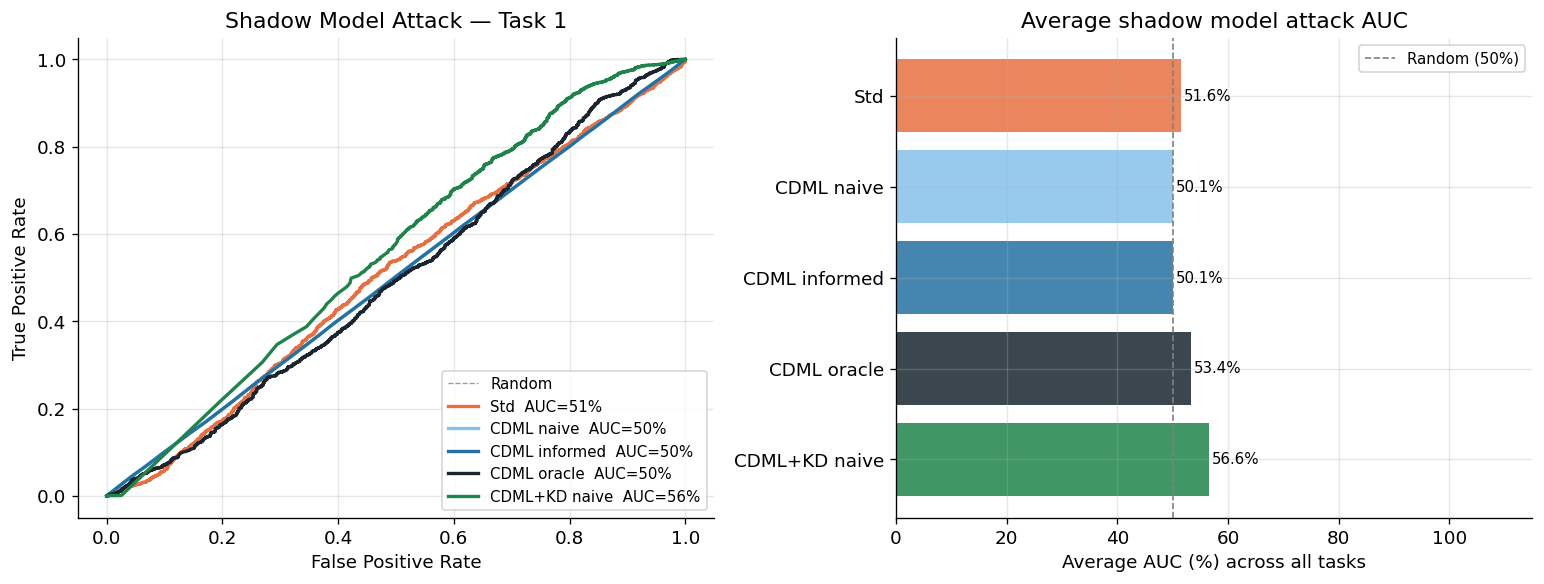

In [19]:
# ── ROC curves ────────────────────────────────────────────────────────────────
method_colors = {
    'Std':            '#E87040',
    'CDML naive':     '#85C1E9',
    'CDML informed':  '#2471A3',
    'CDML oracle':    '#1A252F',
    'CDML+KD naive':  '#1E8449',
}
FOCUS = 'Task 1'   # Task 1 is most interesting: it was trained earliest, most at risk of forgetting

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: ROC for focus task
ax = axes[0]
ax.plot([0,1],[0,1], 'k--', lw=0.8, alpha=0.4, label='Random')
for label, res in all_results:
    fpr, tpr = res[FOCUS]['fpr'], res[FOCUS]['tpr']
    roc_auc  = res[FOCUS]['auc']
    ax.plot(fpr, tpr, color=method_colors[label], lw=2,
            label=f'{label}  AUC={roc_auc*100:.0f}%')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title(f'Shadow Model Attack — {FOCUS}')
ax.legend(fontsize=9, loc='lower right')

# Right: avg AUC across tasks per method (bar chart)
ax2 = axes[1]
labels_list = [label for label, _ in all_results]
avg_aucs    = [np.mean([res[t]['auc']*100 for t in task_names]) for _, res in all_results]
colors_list = [method_colors[label] for label in labels_list]
bars = ax2.barh(labels_list[::-1], avg_aucs[::-1], color=colors_list[::-1], alpha=0.85)
ax2.axvline(50, color='gray', linestyle='--', lw=1, label='Random (50%)')
for bar, val in zip(bars, avg_aucs[::-1]):
    ax2.text(val + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=9)
ax2.set_xlabel('Average AUC (%) across all tasks')
ax2.set_title('Average shadow model attack AUC')
ax2.set_xlim(0, 115)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig_shadow_attack.png', bbox_inches='tight')
plt.show()

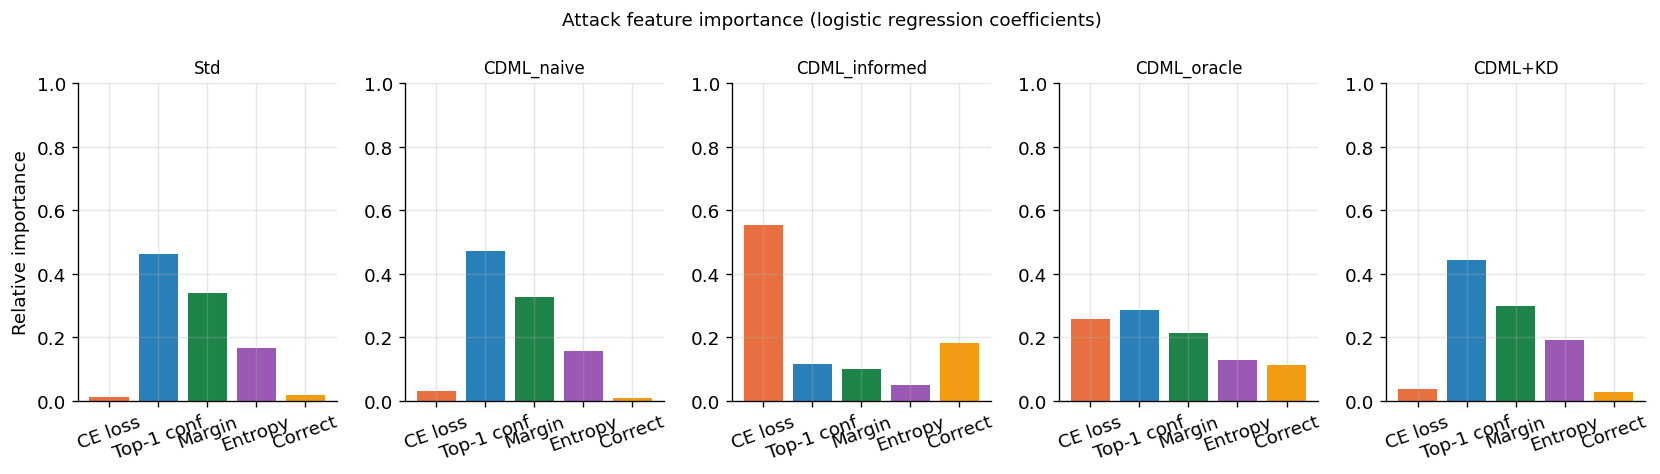

Feature importance tells you which signal the attacker actually exploits:
  CE loss dominant -> attack succeeds via confidence gap (model overfits training data)
  Entropy dominant -> attack exploits prediction certainty distribution
  Low importance everywhere -> features are not informative (CDML protected)


In [20]:
# ── Feature importance: which features drive the attack? ──────────────────────
fig, axes = plt.subplots(1, len(attack_clfs), figsize=(14, 4))

for ax, (key, (clf, _)) in zip(axes, attack_clfs.items()):
    coefs = np.abs(clf.coef_[0])   # logistic regression coefficients
    coefs_norm = coefs / coefs.sum()
    bars = ax.bar(FEATURE_NAMES, coefs_norm,
                  color=['#E87040','#2980B9','#1E8449','#9B59B6','#F39C12'])
    ax.set_title(key, fontsize=10)
    ax.set_ylabel('Relative importance' if ax is axes[0] else '')
    ax.tick_params(axis='x', rotation=20)
    ax.set_ylim(0, 1)

fig.suptitle('Attack feature importance (logistic regression coefficients)', fontsize=11)
plt.tight_layout()
plt.savefig('fig_shadow_feature_importance.png', bbox_inches='tight')
plt.show()

print('Feature importance tells you which signal the attacker actually exploits:')
print('  CE loss dominant -> attack succeeds via confidence gap (model overfits training data)')
print('  Entropy dominant -> attack exploits prediction certainty distribution')
print('  Low importance everywhere -> features are not informative (CDML protected)')

In [21]:
# ── Compare shadow model attack vs simple CE threshold (Phase 4) ──────────────
@torch.no_grad()
def ce_threshold_auc(model, task_data, task_names, device, cdml_seed=None):
    """Simple CE loss threshold attack from Phase 4 — baseline comparison."""
    criterion = nn.CrossEntropyLoss(reduction='none')
    aucs = {}
    for t_idx, task_name in enumerate(task_names):
        if cdml_seed is not None and hasattr(model, 'set_task_sequence'):
            if cdml_seed == 'oracle':
                model.set_task_sequence(task_name, CDML_SEED_BASE + t_idx)
            else:
                model.cdml.sequence = torch.zeros(
                    model.embed_dim, device=next(model.parameters()).device)
        model.eval()
        def get_scores(ds):
            loader = DataLoader(ds, batch_size=256, shuffle=False)
            s = []
            for X_b, y_b in loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                s.append(-criterion(model(X_b), y_b).cpu().float().numpy())
            return np.concatenate(s)
        m  = get_scores(task_data[task_name]['train'])
        nm = get_scores(task_data[task_name]['test'])
        scores = np.concatenate([m, nm])
        labels = np.concatenate([np.ones(len(m)), np.zeros(len(nm))])
        fpr, tpr, _ = roc_curve(labels, scores)
        aucs[task_name] = sk_auc(fpr, tpr)
    return aucs

ce_std         = ce_threshold_auc(target_std,     task_data, task_names, DEVICE)
ce_cdml_noseed = ce_threshold_auc(target_cdml,    task_data, task_names, DEVICE, cdml_seed='noseed')
# KD-CL target is plain GaitCNN — no CDML, so no cdml_seed argument needed
ce_cdml_kd     = ce_threshold_auc(target_kd,      task_data, task_names, DEVICE)

print('── Shadow attack vs CE threshold: average AUC across tasks ──')
print(f'  {"Method":<28}  {"Shadow AUC":>12}  {"CE threshold AUC":>18}  {"Shadow - CE":>12}')
print('  ' + '─' * 74)
comparisons = [
    ('Std',            results_std,         ce_std),
    ('CDML naive',     results_cdml_naive,  ce_cdml_noseed),
    ('CDML+KD naive',  results_cdml_kd,     ce_cdml_kd),
]
for label, shadow_res, ce_aucs in comparisons:
    shadow_avg = np.mean([shadow_res[t]['auc']*100 for t in task_names])
    ce_avg     = np.mean([ce_aucs[t]*100 for t in task_names])
    print(f'  {label:<28}  {shadow_avg:>11.1f}%  {ce_avg:>17.1f}%  {shadow_avg-ce_avg:>+11.1f}pp')

print()
print('If Shadow > CE threshold: the learned attack finds additional signals')
print('If Shadow ≈ CE threshold: CE loss is already the dominant signal')

── Shadow attack vs CE threshold: average AUC across tasks ──
  Method                          Shadow AUC    CE threshold AUC   Shadow - CE
  ──────────────────────────────────────────────────────────────────────────
  Std                                  51.6%               52.9%         -1.3pp
  CDML naive                           50.1%               50.1%         -0.0pp
  CDML+KD naive                        56.6%               59.6%         -3.0pp

If Shadow > CE threshold: the learned attack finds additional signals
If Shadow ≈ CE threshold: CE loss is already the dominant signal


## 11. Summary and thesis discussion guide

### What the results should show

**Std:** Shadow attack AUC should be **high (80–95%)**. The learned classifier exploits the same CE loss gap we found in Phase 4, possibly enhanced by entropy and margin features.

**CDML naive attacker:** AUC should be **near 50%**. The shadow classifier was trained on plain GaitCNN outputs; when applied to the CDML target with zeroed sequence, there is no informative signal because all embeddings collapse to zero → CE loss is identical for everyone.

**CDML informed attacker:** AUC should also be **near 50%**. Even knowing CDML exists and training shadow models with CDML (wrong seeds), the attack still cannot transfer — the classifier learned to exploit membership signals under a specific sequence, and those signals don't generalise to a different sequence.

**CDML oracle:** AUC should be **high**, comparable to Std. This is the theoretical upper bound: if the attacker has the seed, CDML provides no privacy protection, just like a standard model. This is the intended result — CDML's security model is key-based, not obscurity-based.

**CDML+KD naive:** The key comparison. If AUC is similar to CDML naive: KD adds no extra vulnerability beyond CDML. If higher: the distillation term (which keeps outputs close to the old model) creates a predictable pattern that the shadow classifier can learn, independent of the CDML sequence.

### Feature importance

The feature importance plot tells you *why* the attack succeeds or fails:
- Std: CE loss and Top-1 confidence should dominate (classic overfitting signal)
- CDML: features should be near-uniform importance or all near-zero (no signal)
- CDML+KD: if the distillation term creates extra vulnerability, entropy or margin may become informative

### Comparison with Phase 4 CE threshold

This tells you whether the shadow model learned anything *beyond* the simple threshold:
- If shadow ≈ CE threshold: the CE loss is already the dominant membership signal; a learned attack adds nothing
- If shadow > CE threshold: there are additional signals (confidence distribution shape, entropy) that the threshold missed

This comparison is itself a contribution: it characterises the *complexity* of the membership signal in gait IMU data.

---
*Notebook: phase8_shadow_attack.ipynb*